# 01 - Data quality & EDA
What is in the data, what was wrong, and what patterns exist.

In [1]:
import sys; sys.path.append('..')
import sqlite3, pandas as pd, matplotlib.pyplot as plt
con = sqlite3.connect('../data/stocksense.db')
rd = lambda t: pd.read_sql(f'select * from {t}', con)

## Problems found and fixed (all fixed in code, see `src/pipeline.py`)

In [2]:
rd('data_quality')

,issue,rows_affected,how_handled
0,Inconsistent category labels,3,"Trimmed spaces, unified capitalisation"
1,Duplicate sales rows,25,Removed
2,Missing units_sold,30,Recovered as revenue / unit_price
3,Rows left with missing values,0,None - all fixed


## Sales table (one row per product per day)

In [3]:
s = rd('sales_daily'); s['date'] = pd.to_datetime(s.date); s.head()

,date,sku_id,units_sold,revenue,unit_price,promo_flag
0,2024-01-01,K01,8.0,3192.0,399.0,0
1,2024-01-02,K01,6.0,2394.0,399.0,0
2,2024-01-03,K01,5.0,1995.0,399.0,0
3,2024-01-04,K01,5.0,1995.0,399.0,0
4,2024-01-05,K01,5.0,1995.0,399.0,0


## Sales are seasonal: units per month, per product

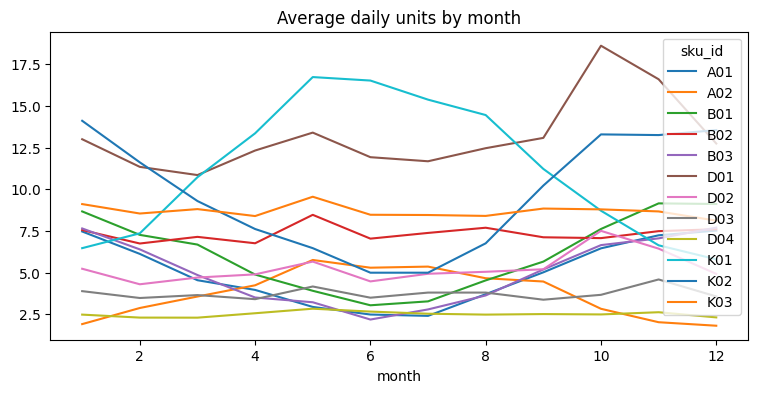

In [4]:
s['month'] = s.date.dt.month
s.groupby(['month','sku_id']).units_sold.mean().unstack().plot(figsize=(9,4), title='Average daily units by month'); plt.show()

## Top sellers by revenue

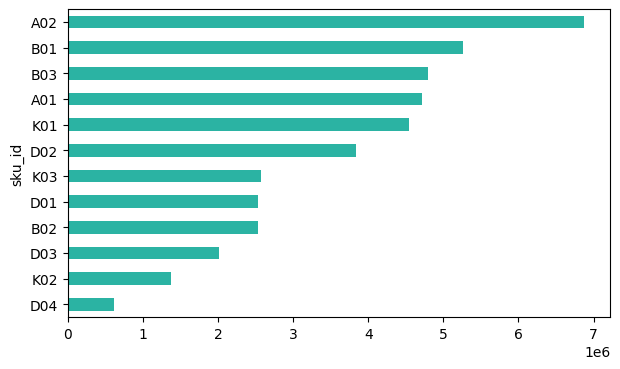

In [5]:
s.groupby('sku_id').revenue.sum().sort_values().plot.barh(figsize=(7,4), color='#2BB3A3'); plt.show()

## Sale days vs normal days

In [6]:
(s[s.promo_flag==1].groupby('sku_id').units_sold.mean() / s[s.promo_flag==0].groupby('sku_id').units_sold.mean()).round(2)

sku_id
A01    1.48
A02    1.27
B01    1.32
B02    1.50
B03    1.47
D01    1.47
D02    1.54
D03    1.29
D04    1.39
K01    1.28
K02    1.44
K03    1.35
Name: units_sold, dtype: float64